FASE 8B — LANGKAH 8B.1: XGBoost Classifier

  SETUP & LOAD DATA — FASE 8B XGBOOST CLASSIFIER
  X_train    : (20504, 69)
  y_train    : (20504,)
  X_val      : (3288, 69)
  y_val      : (3288,)
  X_test     : (2716, 69)
  y_test     : (2716,)

  BAGIAN 1 — TRAINING XGBOOST

  Hyperparameters:
    n_estimators               : 500
    max_depth                  : 6
    learning_rate              : 0.05
    subsample                  : 0.8
    colsample_bytree           : 0.8
    min_child_weight           : 3
    gamma                      : 0.1
    reg_alpha                  : 0.1
    reg_lambda                 : 1.0
    objective                  : multi:softprob
    num_class                  : 3
    eval_metric                : mlogloss
    early_stopping_rounds      : 30
    random_state               : 42
    n_jobs                     : -1
    verbosity                  : 0

  Fitting XGBClassifier (max 500 trees, early_stopping=30)...
  [OK] Training selesai.
  Best iteration     : 40
  Best Val mlogloss  : 0.317764

  BAGI

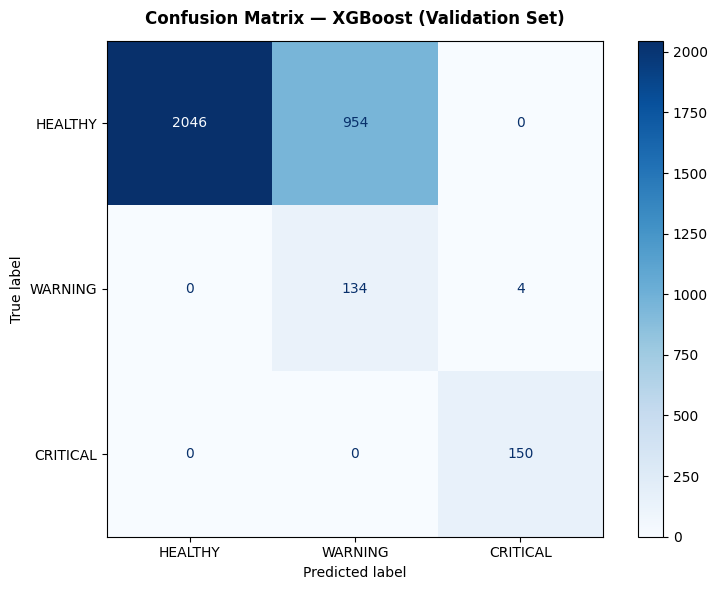


  BAGIAN 3 — EVALUASI PADA TEST SET

  F1-Score Macro (Test) : 0.9899
  Accuracy (Test)       : 0.9974

-----------------------------------------------------------------
  Classification Report (Test Set)
-----------------------------------------------------------------

              precision    recall  f1-score   support

     HEALTHY     0.9996    1.0000    0.9998      2283
     WARNING     0.9809    0.9856    0.9832       208
    CRITICAL     0.9910    0.9822    0.9866       225

    accuracy                         0.9974      2716
   macro avg     0.9905    0.9893    0.9899      2716
weighted avg     0.9974    0.9974    0.9974      2716



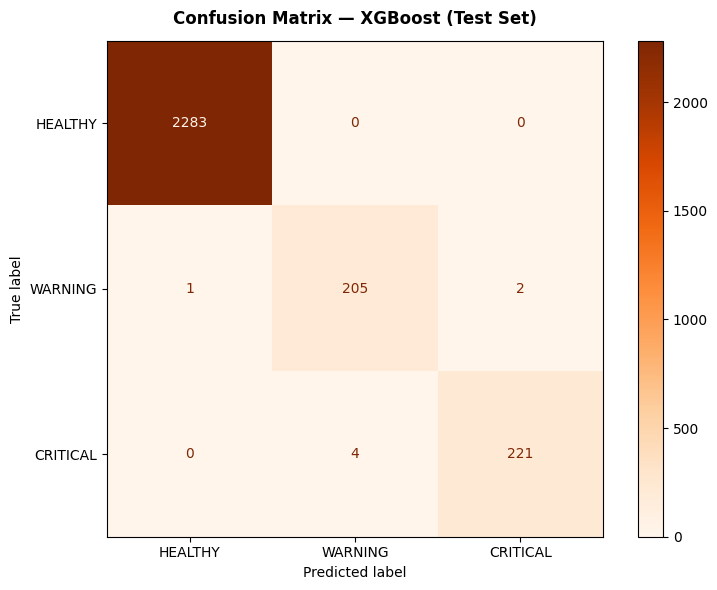


  BAGIAN 4 — FEATURE IMPORTANCE


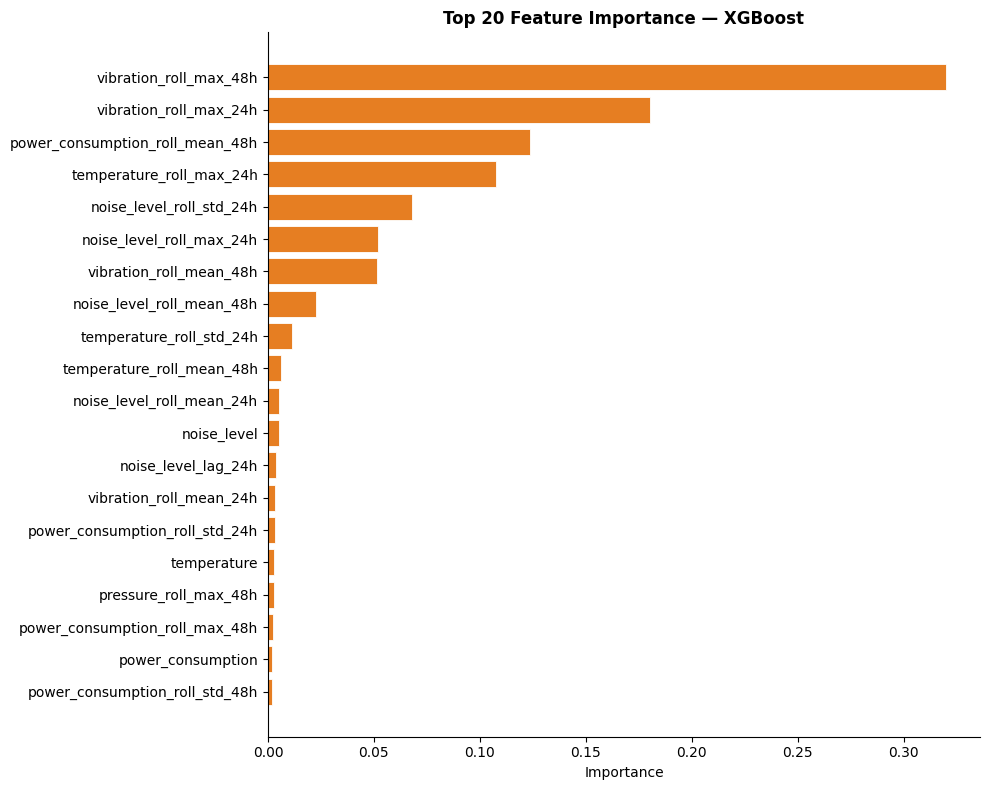


  Rank    Feature                                        Importance
  -----------------------------------------------------------------
  1       vibration_roll_max_48h                           0.320035
  2       vibration_roll_max_24h                           0.180097
  3       power_consumption_roll_mean_48h                  0.123645
  4       temperature_roll_max_24h                         0.107759
  5       noise_level_roll_std_24h                         0.068149
  6       noise_level_roll_max_24h                         0.051736
  7       vibration_roll_mean_48h                          0.051380
  8       noise_level_roll_mean_48h                        0.022643
  9       temperature_roll_std_24h                         0.011528
  10      temperature_roll_mean_48h                        0.006256
  11      noise_level_roll_mean_24h                        0.005409
  12      noise_level                                      0.005119
  13      noise_level_lag_24h                  

In [1]:
# FASE 8B — XGBoost Classifier: Setup + Training + Evaluasi
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt, joblib
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay)

NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from config import DATA_PROCESSED_DIR, MODELS_ML_DIR, GLOBAL_SEED

SEP = "=" * 65
sep = "-" * 65
LABEL_NAMES = ["HEALTHY", "WARNING", "CRITICAL"]

# --- LOAD DATA ---
print(SEP)
print("  SETUP & LOAD DATA — FASE 8B XGBOOST CLASSIFIER")
print(SEP)

X_train = pd.read_parquet(DATA_PROCESSED_DIR / "X_train_clf.parquet")
y_train = pd.read_parquet(DATA_PROCESSED_DIR / "y_train_clf.parquet").squeeze()
X_val   = pd.read_parquet(DATA_PROCESSED_DIR / "X_val_clf.parquet")
y_val   = pd.read_parquet(DATA_PROCESSED_DIR / "y_val_clf.parquet").squeeze()
X_test  = pd.read_parquet(DATA_PROCESSED_DIR / "X_test_clf.parquet")
y_test  = pd.read_parquet(DATA_PROCESSED_DIR / "y_test_clf.parquet").squeeze()

for name, obj in [("X_train", X_train), ("y_train", y_train),
                   ("X_val",   X_val),   ("y_val",   y_val),
                   ("X_test",  X_test),  ("y_test",  y_test)]:
    shape = obj.shape if hasattr(obj, "shape") else (len(obj),)
    print(f"  {name:<10} : {shape}")

# ════════════════════════════════════════════════════════════
# BAGIAN 1 — TRAINING XGBOOST
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  BAGIAN 1 — TRAINING XGBOOST")
print(SEP)

XGB_PARAMS = {
    "n_estimators"         : 500,
    "max_depth"            : 6,
    "learning_rate"        : 0.05,
    "subsample"            : 0.8,
    "colsample_bytree"     : 0.8,
    "min_child_weight"     : 3,
    "gamma"                : 0.1,
    "reg_alpha"            : 0.1,
    "reg_lambda"           : 1.0,
    "objective"            : "multi:softprob",
    "num_class"            : 3,
    "eval_metric"          : "mlogloss",
    "early_stopping_rounds": 30,
    "random_state"         : GLOBAL_SEED,
    "n_jobs"               : -1,
    "verbosity"            : 0,
}

print("\n  Hyperparameters:")
for k, v in XGB_PARAMS.items():
    print(f"    {k:<26} : {v}")

print(f"\n  Fitting XGBClassifier (max {XGB_PARAMS['n_estimators']} trees, "
      f"early_stopping={XGB_PARAMS['early_stopping_rounds']})...")

xgb_model = XGBClassifier(**XGB_PARAMS)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print(f"  [OK] Training selesai.")
print(f"  Best iteration     : {xgb_model.best_iteration}")
print(f"  Best Val mlogloss  : {xgb_model.best_score:.6f}")

# ════════════════════════════════════════════════════════════
# BAGIAN 2 — EVALUASI VALIDATION SET
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  BAGIAN 2 — EVALUASI PADA VALIDATION SET")
print(SEP)

y_val_pred    = xgb_model.predict(X_val)
f1_macro_val  = f1_score(y_val, y_val_pred, average="macro")
accuracy_val  = accuracy_score(y_val, y_val_pred)

print(f"\n  F1-Score Macro (Val) : {f1_macro_val:.4f}")
print(f"  Accuracy (Val)       : {accuracy_val:.4f}")
print(f"\n{sep}")
print("  Classification Report (Validation Set)")
print(sep)
print()
print(classification_report(y_val, y_val_pred, target_names=LABEL_NAMES, digits=4))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(y_val, y_val_pred),
                       display_labels=LABEL_NAMES).plot(ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — XGBoost (Validation Set)",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════
# BAGIAN 3 — EVALUASI TEST SET
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  BAGIAN 3 — EVALUASI PADA TEST SET")
print(SEP)

y_test_pred   = xgb_model.predict(X_test)
f1_macro_test = f1_score(y_test, y_test_pred, average="macro")
accuracy_test = accuracy_score(y_test, y_test_pred)

print(f"\n  F1-Score Macro (Test) : {f1_macro_test:.4f}")
print(f"  Accuracy (Test)       : {accuracy_test:.4f}")
print(f"\n{sep}")
print("  Classification Report (Test Set)")
print(sep)
print()
print(classification_report(y_test, y_test_pred, target_names=LABEL_NAMES, digits=4))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_test_pred),
                       display_labels=LABEL_NAMES).plot(ax=ax, cmap="Oranges")
ax.set_title("Confusion Matrix — XGBoost (Test Set)",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════
# BAGIAN 4 — FEATURE IMPORTANCE
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  BAGIAN 4 — FEATURE IMPORTANCE")
print(SEP)

fi_df_xgb = (
    pd.DataFrame({"feature": X_train.columns,
                  "importance": xgb_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = fi_df_xgb.head(20)
ax.barh(top20["feature"][::-1], top20["importance"][::-1],
        color="#e67e22", edgecolor="white", linewidth=0.6)
ax.set_title("Top 20 Feature Importance — XGBoost",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importance", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(f"\n  {'Rank':<6}  {'Feature':<45}  {'Importance':>10}")
print(f"  {'-'*65}")
for i, row in top20.iterrows():
    print(f"  {i+1:<6}  {row['feature']:<45}  {row['importance']:>10.6f}")

# ════════════════════════════════════════════════════════════
# BAGIAN 5 — COMPARISON TABLE vs RANDOM FOREST
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  BAGIAN 5 — COMPARISON TABLE: XGBoost vs Random Forest")
print(SEP)

RF_SCORES = {
    "F1 Val"  : 0.9292,
    "F1 Test" : 0.9914,
    "Acc Val" : 0.9808,
    "Acc Test": 0.9978,
}

XGB_SCORES = {
    "F1 Val"  : f1_macro_val,
    "F1 Test" : f1_macro_test,
    "Acc Val" : accuracy_val,
    "Acc Test": accuracy_test,
}

print(f"\n  {'Metrik':<14}  {'Random Forest':>14}  {'XGBoost':>10}  {'Delta':>8}")
print(f"  {'-'*52}")
for metric in RF_SCORES:
    rf_val  = RF_SCORES[metric]
    xgb_val = XGB_SCORES[metric]
    delta   = xgb_val - rf_val
    flag    = "▲" if delta > 0 else "▼"
    print(f"  {metric:<14}  {rf_val:>14.4f}  {xgb_val:>10.4f}  "
          f"{delta:>+8.4f} {flag}")

print()
diff_f1_val = f1_macro_val - RF_SCORES["F1 Val"]
if diff_f1_val > 0.01:
    print("  ✅ XGBoost LEBIH BAIK dari Random Forest")
elif diff_f1_val < -0.01:
    print("  📊 Random Forest masih unggul di Val Set")
else:
    print("  🤝 Performa setara — pertimbangkan kecepatan inferensi")

# ════════════════════════════════════════════════════════════
# BAGIAN 6 — SIMPAN MODEL
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  BAGIAN 6 — SIMPAN MODEL")
print(SEP)

MODELS_ML_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_ML_DIR / "xgb_classifier.pkl"
joblib.dump(xgb_model, MODEL_PATH)
model_mb = MODEL_PATH.stat().st_size / (1024 ** 2)

print(f"\n  Path tersimpan  : {MODEL_PATH}")
print(f"  Ukuran file     : {model_mb:.2f} MB")
print(f"  Best iteration  : {xgb_model.best_iteration}")
print(f"\n{sep}")
print("  RINGKASAN PERFORMA AKHIR")
print(sep)
print(f"\n  F1-Score Macro (Val)  : {f1_macro_val:.4f}")
print(f"  F1-Score Macro (Test) : {f1_macro_test:.4f}")
print(f"  Accuracy (Val)        : {accuracy_val:.4f}")
print(f"  Accuracy (Test)       : {accuracy_test:.4f}")
gap = abs(f1_macro_val - f1_macro_test)
flag = "[OK] Stabil" if gap < 0.05 else "[WARN] Gap > 0.05"
print(f"  Gap Val vs Test (F1)  : {gap:.4f}  →  {flag}")

print(f"\n{SEP}")
print("  [OK] XGBoost Classifier — Fase 8B SELESAI.")
print(f"  [OK] Model disimpan : xgb_classifier.pkl  ({model_mb:.2f} MB)")
print(SEP)


LANGKAH 8B.2 — XGBoost Hyperparameter Tuning

In [2]:
# ============================================================
# FASE 8B — Cell 2: XGBoost Tuning — Fix Val Performance
# ============================================================

import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report

SEP = "=" * 65
sep = "-" * 65
LABEL_NAMES = ["HEALTHY", "WARNING", "CRITICAL"]

# ════════════════════════════════════════════════════════════
# STRATEGI 1 — RETRAIN DENGAN PARAMETER ADJUSTED (V2)
# ════════════════════════════════════════════════════════════
print(SEP)
print("  STRATEGI 1 — XGBoost V2 (Parameter Adjusted)")
print(SEP)

XGB_PARAMS_V2 = {
    "n_estimators"         : 500,
    "max_depth"            : 4,      # 6→4: kurangi kompleksitas
    "learning_rate"        : 0.01,   # 0.05→0.01: lebih konservatif
    "subsample"            : 0.8,
    "colsample_bytree"     : 0.8,
    "min_child_weight"     : 5,      # 3→5: lebih konservatif minority
    "gamma"                : 0.2,    # 0.1→0.2: split threshold lebih ketat
    "reg_alpha"            : 0.5,    # 0.1→0.5: L1 lebih kuat
    "reg_lambda"           : 2.0,    # 1.0→2.0: L2 lebih kuat
    "objective"            : "multi:softprob",
    "num_class"            : 3,
    "eval_metric"          : "mlogloss",
    "early_stopping_rounds": 50,     # 30→50: lebih banyak kesempatan
    "random_state"         : GLOBAL_SEED,
    "n_jobs"               : -1,
    "verbosity"            : 0,
}

print("\n  Perubahan parameter dari V1:")
changes = {
    "max_depth"            : "6 → 4  (generalisasi lebih baik)",
    "learning_rate"        : "0.05 → 0.01  (lebih hati-hati)",
    "min_child_weight"     : "3 → 5  (konservatif di minority)",
    "gamma"                : "0.1 → 0.2  (split lebih ketat)",
    "reg_alpha"            : "0.1 → 0.5  (L1 lebih kuat)",
    "reg_lambda"           : "1.0 → 2.0  (L2 lebih kuat)",
    "early_stopping_rounds": "30 → 50  (lebih banyak kesempatan)",
}
for k, v in changes.items():
    print(f"    {k:<26} : {v}")

print(f"\n  Fitting XGBoost V2...")
xgb_v2 = XGBClassifier(**XGB_PARAMS_V2)
xgb_v2.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print(f"  [OK] Training selesai.")
print(f"  Best iteration     : {xgb_v2.best_iteration}")
print(f"  Best Val mlogloss  : {xgb_v2.best_score:.6f}")

# ════════════════════════════════════════════════════════════
# STRATEGI 2 — THRESHOLD OPTIMIZATION UNTUK WARNING
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  STRATEGI 2 — THRESHOLD OPTIMIZATION (WARNING CLASS)")
print(SEP)

y_val_proba_v2 = xgb_v2.predict_proba(X_val)  # [P(HEALTHY), P(WARNING), P(CRITICAL)]

# Cari threshold WARNING terbaik
thresholds     = np.arange(0.1, 0.9, 0.05)
best_threshold = 0.5
best_f1        = 0.0

print(f"\n  Sweeping threshold WARNING dari 0.10 → 0.85:")
print(f"\n  {'Threshold':>12}  {'F1 Macro Val':>14}")
print(f"  {'-'*30}")

for thr in thresholds:
    preds = np.where(
        y_val_proba_v2[:, 2] > 0.5, 2,          # CRITICAL
        np.where(y_val_proba_v2[:, 1] > thr, 1,  # WARNING
                 0)                               # HEALTHY
    )
    f1_thr = f1_score(y_val, preds, average="macro")
    flag   = " ← best" if f1_thr > best_f1 else ""
    print(f"  {thr:>12.2f}  {f1_thr:>14.4f}{flag}")
    if f1_thr > best_f1:
        best_f1        = f1_thr
        best_threshold = thr

print(f"\n  Best threshold WARNING : {best_threshold:.2f}")
print(f"  Best F1 Macro Val     : {best_f1:.4f}")

# Fungsi predict dengan threshold
def predict_with_threshold(proba: np.ndarray, threshold: float) -> np.ndarray:
    """
    Custom prediction dengan threshold untuk WARNING class.
    Priority: CRITICAL > WARNING(threshold) > HEALTHY
    """
    return np.where(
        proba[:, 2] > 0.5,          # CRITICAL
        2,
        np.where(proba[:, 1] > threshold, 1,  # WARNING
                 0)                            # HEALTHY
    )

y_val_pred_tuned  = predict_with_threshold(y_val_proba_v2, best_threshold)
y_test_pred_tuned = predict_with_threshold(
    xgb_v2.predict_proba(X_test), best_threshold
)

# ════════════════════════════════════════════════════════════
# EVALUASI — TIGA SKENARIO
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  EVALUASI HASIL TUNING — 3 SKENARIO")
print(SEP)

# V1 scores (hardcoded dari cell sebelumnya)
V1_F1_VAL    = 0.6721
V1_F1_TEST   = 0.9899
V1_WARN_F1   = 0.2186

# V2 scores
y_val_pred_v2  = xgb_v2.predict(X_val)
y_test_pred_v2 = xgb_v2.predict(X_test)

f1_val_v2  = f1_score(y_val,  y_val_pred_v2,  average="macro")
f1_test_v2 = f1_score(y_test, y_test_pred_v2, average="macro")
warn_f1_v2 = f1_score(y_val,  y_val_pred_v2,  average=None)[1]

# V2 + Tuning scores
f1_val_tuned  = f1_score(y_val,  y_val_pred_tuned,  average="macro")
f1_test_tuned = f1_score(y_test, y_test_pred_tuned, average="macro")
warn_f1_tuned = f1_score(y_val,  y_val_pred_tuned,  average=None)[1]

# --- Print Classification Reports ---
for label, y_pred, title in [
    ("B — V2 Adjusted (Val)",       y_val_pred_v2,  "SKENARIO B — XGBoost V2"),
    ("B — V2 Adjusted (Test)",      y_test_pred_v2, "SKENARIO B — XGBoost V2 (Test)"),
    ("C — V2 + Threshold (Val)",    y_val_pred_tuned,  "SKENARIO C — V2 + Tuning (Val)"),
    ("C — V2 + Threshold (Test)",   y_test_pred_tuned, "SKENARIO C — V2 + Tuning (Test)"),
]:
    y_true = y_val if "Val" in label else y_test
    print(f"\n{sep}")
    print(f"  {title}")
    print(sep)
    print(classification_report(y_true, y_pred,
                                target_names=LABEL_NAMES, digits=4))

# --- Tabel Perbandingan ---
print(f"\n{sep}")
print("  TABEL PERBANDINGAN KETIGA SKENARIO")
print(sep)
print()
print(f"  {'Skenario':<22}  {'F1 Val':>8}  {'F1 Test':>9}  {'WARNING F1 Val':>15}")
print(f"  {'-'*60}")
print(f"  {'V1 Original':<22}  {V1_F1_VAL:>8.4f}  {V1_F1_TEST:>9.4f}  {V1_WARN_F1:>15.4f}")
print(f"  {'V2 Adjusted':<22}  {f1_val_v2:>8.4f}  {f1_test_v2:>9.4f}  {warn_f1_v2:>15.4f}")
print(f"  {'V2 + Threshold':<22}  {f1_val_tuned:>8.4f}  {f1_test_tuned:>9.4f}  {warn_f1_tuned:>15.4f}")

# Verdict
scores = {
    "V1 Original"   : V1_F1_VAL,
    "V2 Adjusted"   : f1_val_v2,
    "V2 + Threshold": f1_val_tuned,
}
best_scenario = max(scores, key=scores.get)

print(f"\n{sep}")
print("  VERDICT")
print(sep)
print(f"\n  Skenario terbaik (F1 Val) : {best_scenario} ({scores[best_scenario]:.4f})")
if best_scenario == "V2 + Threshold":
    print("  ✅ Threshold tuning berhasil memperbaiki performa Val.")
elif best_scenario == "V2 Adjusted":
    print("  ✅ Parameter adjustment sudah cukup — threshold tidak diperlukan.")
else:
    print("  📊 V1 Original masih unggul — investigasi lebih lanjut diperlukan.")

# ════════════════════════════════════════════════════════════
# SIMPAN MODEL TERBAIK (xgb_v2)
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  SIMPAN MODEL — xgb_v2 (overwrite xgb_classifier.pkl)")
print(SEP)

import joblib, sys
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from config import MODELS_ML_DIR

MODELS_ML_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_ML_DIR / "xgb_classifier.pkl"
joblib.dump(xgb_v2, MODEL_PATH)
model_mb = MODEL_PATH.stat().st_size / (1024 ** 2)

print(f"\n  Path tersimpan  : {MODEL_PATH}")
print(f"  Ukuran file     : {model_mb:.2f} MB")
print(f"  Best iteration  : {xgb_v2.best_iteration}")
print(f"  [OK] xgb_classifier.pkl berhasil di-overwrite dengan V2.")

print(f"\n{SEP}")
print("  [OK] XGBoost Tuning — SELESAI.")
print(SEP)


  STRATEGI 1 — XGBoost V2 (Parameter Adjusted)

  Perubahan parameter dari V1:
    max_depth                  : 6 → 4  (generalisasi lebih baik)
    learning_rate              : 0.05 → 0.01  (lebih hati-hati)
    min_child_weight           : 3 → 5  (konservatif di minority)
    gamma                      : 0.1 → 0.2  (split lebih ketat)
    reg_alpha                  : 0.1 → 0.5  (L1 lebih kuat)
    reg_lambda                 : 1.0 → 2.0  (L2 lebih kuat)
    early_stopping_rounds      : 30 → 50  (lebih banyak kesempatan)

  Fitting XGBoost V2...
  [OK] Training selesai.
  Best iteration     : 499
  Best Val mlogloss  : 0.121466

  STRATEGI 2 — THRESHOLD OPTIMIZATION (WARNING CLASS)

  Sweeping threshold WARNING dari 0.10 → 0.85:

     Threshold    F1 Macro Val
  ------------------------------
          0.10          0.6656 ← best
          0.15          0.6668 ← best
          0.20          0.6685 ← best
          0.25          0.7232 ← best
          0.30          0.8292 ← best
      